# Analise Venda

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Leitura de Dados

In [2]:
df = pd.read_excel("dados_vendas_brutos_corrigidos.xlsx", engine="openpyxl")

Visualização dos Dados

In [3]:
display(df.sample(10))
display(df.info())
display(df.dtypes)
display(df.isnull().sum())

,id_venda,data,loja,produto,categoria,quantidade,preco_unitario
2301,3301,2024-06-13,Loja Oeste,Jaqueta Esportiva,Vestuário Esportivo,1,291.38
1127,2127,2024-03-24,Loja Centro,Jaqueta de Couro,Vestuário Premium,1,864.03
466,1466,2024-02-05,Loja Oeste,Meias,Acessórios,15,14.93
4645,5645,2024-12-06,Loja Oeste,Jaqueta Esportiva,Vestuário Esportivo,4,298.09
1765,2765,2024-05-08,Loja Norte,Calça Jeans,Vestuário Casual,2,93.71
3925,4925,2024-10-14,Loja Oeste,Jaqueta Esportiva,Vestuário Esportivo,1,294.91
1763,2763,2024-05-08,Loja Sul,Vestido,Vestuário Feminino,2,201.47
1990,2990,2024-05-25,Loja Sul,Camiseta Premium,Vestuário Premium,3,123.95
4483,5483,2024-11-23,Loja Sul,Óculos de Sol,Acessórios Premium,5,232.36
11,1011,2024-01-01,Loja Leste,Óculos de Sol,Acessórios Premium,3,257.00


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_venda        5000 non-null   int64         
 1   data            5000 non-null   datetime64[us]
 2   loja            5000 non-null   str           
 3   produto         5000 non-null   str           
 4   categoria       5000 non-null   str           
 5   quantidade      5000 non-null   int64         
 6   preco_unitario  5000 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 273.6 KB


None

id_venda                   int64
data              datetime64[us]
loja                         str
produto                      str
categoria                    str
quantidade                 int64
preco_unitario           float64
dtype: object

id_venda          0
data              0
loja              0
produto           0
categoria         0
quantidade        0
preco_unitario    0
dtype: int64

Limpeza e Análise das Datas

In [4]:
df["data"] = pd.to_datetime(df["data"], errors="coerce")

df["nome_mes"] = df["data"].dt.month_name(locale="pt_BR")
df["nome_dia"] = df["data"].dt.day_name(locale="pt_BR")
df["mes_ano"] = df["data"].dt.to_period("M")

Enriquecimento da Coluna Valor Venda

In [5]:
df["valor_venda"] = df["quantidade"] * df["preco_unitario"]

Gráfico Produto Venda

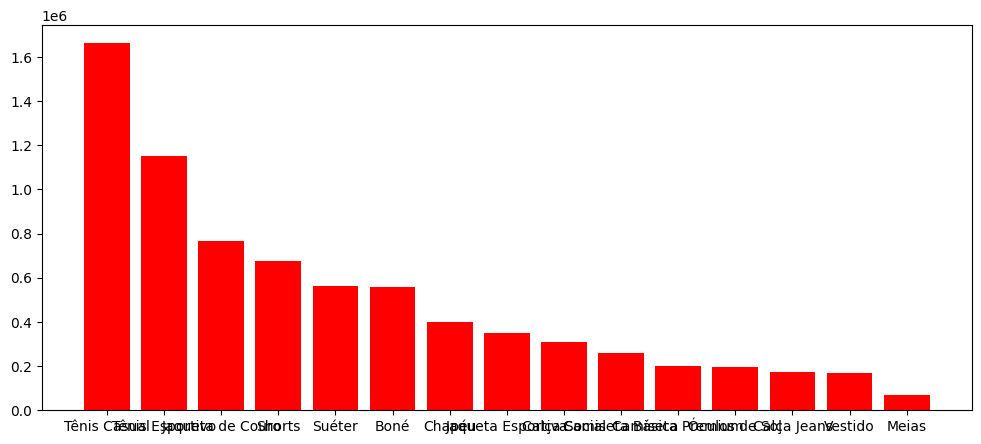

In [6]:
produto_venda = df.groupby("produto").agg(
    total_venda=("valor_venda", "sum")
).reset_index().sort_values("total_venda", ascending=False)

plt.figure(figsize=(12,5))

plt.bar(produto_venda["produto"], produto_venda["total_venda"], color="red")
plt.show()

Gráfico de Barras Faturamento por Loja

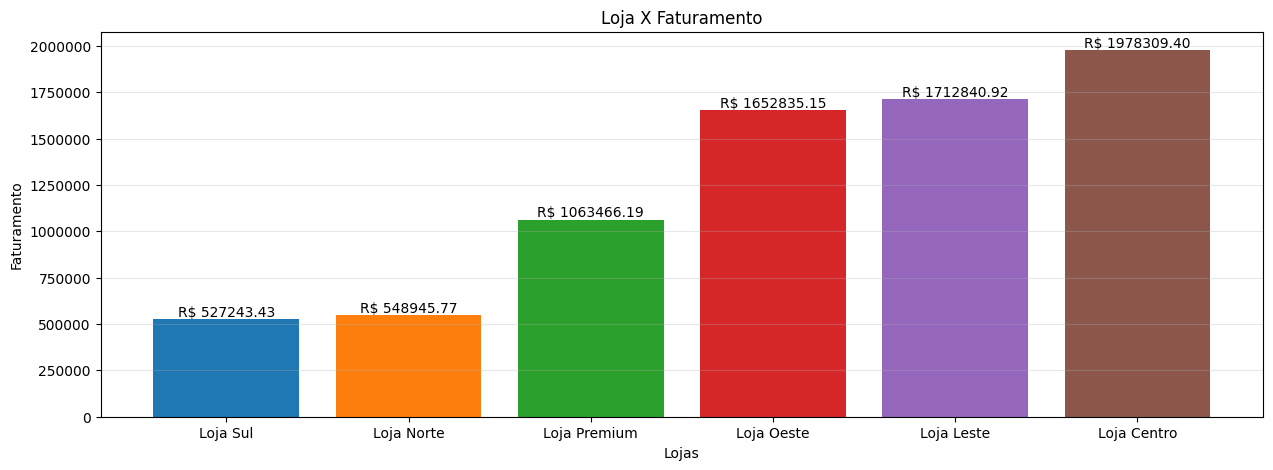

In [ ]:
faturamento_loja = df.groupby("loja").agg(
    total_venda = ("valor_venda", "sum")
).reset_index().sort_values("total_venda", ascending=True)


cores = plt.cm.tab10(range(len(faturamento_loja["loja"])))

plt.figure(figsize=(15,5))

barras = plt.bar(faturamento_loja["loja"], faturamento_loja["total_venda"], color = cores)

plt.title("Loja X Faturamento")

plt.xlabel("Lojas")
plt.ylabel("Faturamento")

plt.ticklabel_format(style="plain", axis="y")

plt.grid(True, axis="y", alpha=0.3)


for bar in barras:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"R$ {bar.get_height():,.2f}",
        ha="center",
        va="bottom"

    )


plt.show()